# 03 - Support Vector Machine (Person 2)
**Task:** predict whether a mortgage is fully prepaid within 24 months (`1`) or not (`0`).
This notebook uses the **saved** files from `01_data_preprocessing.ipynb` (`data/processed/`). It does not preprocess again, re-split, or touch the raw data.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

In [2]:
# ---- Paths: works whether Jupyter is started in the project root or in notebooks/ ----
import os
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
METRICS_DIR = os.path.join(PROJECT_ROOT, "results", "metrics")
PRED_DIR = os.path.join(PROJECT_ROOT, "results", "predictions")
CM_DIR = os.path.join(PROJECT_ROOT, "results", "confusion_matrices")
for d in (METRICS_DIR, PRED_DIR, CM_DIR):
    os.makedirs(d, exist_ok=True)
RANDOM_STATE = 42

## 1. Load and verify the data

In [3]:
# ---- Load the SAVED processed files (no re-preprocessing, no new split) ----
X_train = pd.read_csv(os.path.join(PROCESSED, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED, "y_test.csv")).squeeze("columns")

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Same feature names and order in train and test:", list(X_train.columns) == list(X_test.columns))
print("Rows match targets:", len(X_train) == len(y_train), len(X_test) == len(y_test))
print("Missing values in X (train/test):", int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum()))
print("Target values:", sorted(y_train.unique()), "(1 = prepaid within 24 months = positive class)")
print("Class balance train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class balance test :", y_test.value_counts(normalize=True).round(3).to_dict())

# These numbers come from the assignment text; the notebook only warns if the files differ.
expected = {"train": 39288, "test": 9823, "features": 20}
if (len(X_train), len(X_test), X_train.shape[1]) != (expected["train"], expected["test"], expected["features"]):
    print("WARNING: shapes differ from the 39,288 / 9,823 / 20 described in the assignment. Check the files.")
assert list(X_train.columns) == list(X_test.columns), "Feature columns differ between train and test"
assert len(X_train) == len(y_train) and len(X_test) == len(y_test), "Feature/target length mismatch"

X_train: (39288, 20) | X_test: (9823, 20)
y_train: (39288,) | y_test: (9823,)
Same feature names and order in train and test: True
Rows match targets: True True
Missing values in X (train/test): 0 0
Target values: [np.int64(0), np.int64(1)] (1 = prepaid within 24 months = positive class)
Class balance train: {1: 0.524, 0: 0.476}
Class balance test : {1: 0.524, 0: 0.476}


## 2. Why SVM needs scaled features
An SVM works with **distances** between points (the RBF kernel is built directly from the Euclidean distance). A feature measured in large units, such as `upb` in dollars, would dominate one in small units, such as `ltv` or number of units, purely because of its scale. The preprocessing notebook already standardised the numeric columns using the training set only, so no extra scaling is done here. Doing it again would be redundant, and refitting a scaler on train + test would leak test information.

## 3. SVM concepts (viva notes)
- **Separating hyperplane:** a flat boundary `w.x + b = 0` that splits the two classes in feature space.
- **Maximum margin:** among all separating hyperplanes, the SVM picks the one with the widest gap to the nearest points of either class; a wider margin generally generalises better.
- **Support vectors:** the training points on or inside the margin. Only these define the boundary; moving any other point changes nothing.
- **Soft margin and `C`:** real data overlaps, so some points may violate the margin. `C` is the penalty for violations. Large `C` means few violations tolerated (narrow margin, risk of overfitting); small `C` means a wider, smoother margin (risk of underfitting).
- **Kernel trick:** instead of mapping data to a high-dimensional space explicitly, the kernel `K(x, x')` computes the inner product in that space directly, so a non-linear boundary in the original space is a linear one in the implicit space.
- **RBF kernel:** `K(x, x') = exp(-gamma * ||x - x'||^2)`. Similarity is 1 for identical points and decays towards 0 with distance.
- **`gamma`:** how far one training point's influence reaches. Large `gamma` gives very local, wiggly boundaries (overfitting); small `gamma` gives smooth, nearly linear ones. `gamma="scale"` sets `1 / (n_features * X.var())`.
- **Advantages here:** handles non-linear boundaries, works with 20 features, and is regularised through `C`.
- **Limitations here:** training cost grows roughly between O(n^2) and O(n^3) with samples; no calibrated probabilities by default; the decision score is a signed distance, not a probability; hyperparameters matter; sensitive to class imbalance (the default treats all errors equally).

## 4. Train the RBF SVM
Baseline settings from the assignment: `kernel="rbf"`, `C=1.0`, `gamma="scale"`. No grid search is run, and the test set is never used to choose settings. `class_weight` is left at the default so the model is comparable with the other models; see the interpretation section for how class imbalance affects the results.

In [4]:
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)  # no probability=True: not needed

start = time.time()
svm_model.fit(X_train, y_train)
fit_seconds = time.time() - start

print(f"Training time: {fit_seconds:.1f} s")
print("Support vectors per class:", dict(zip(svm_model.classes_.tolist(), svm_model.n_support_.tolist())))
print(f"Fraction of training points that are support vectors: {svm_model.n_support_.sum() / len(X_train):.3f}")
print("gamma actually used:", svm_model._gamma)

Training time: 230.8 s
Support vectors per class: {0: 14952, 1: 14924}
Fraction of training points that are support vectors: 0.760
gamma actually used: 0.0830573811646918


## 5. Predictions and decision scores

In [5]:
y_pred = svm_model.predict(X_test)
decision_scores = svm_model.decision_function(X_test)   # signed distance to the boundary; larger = more 'prepaid'
print("Classes (sklearn order):", svm_model.classes_, "-> positive score means class", svm_model.classes_[1])
print("Predicted class counts:", pd.Series(y_pred).value_counts().to_dict())

Classes (sklearn order): [0 1] -> positive score means class 1
Predicted class counts: {1: 5427, 0: 4396}


## 6. Evaluation on the existing test set (positive class = 1)

In [6]:
def evaluate(model_name, y_true, y_pred, scores):
    """Same metric definitions for every model. Positive class = 1 (prepayment)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),   # continuous scores, NOT hard 0/1 predictions
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "n_test": int(len(y_true)),
    }


def plot_confusion(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No prepayment (0)", "Prepayment (1)"])
    ax.set_yticklabels(["No prepayment (0)", "Prepayment (1)"])
    ax.set_xlabel("Predicted class"); ax.set_ylabel("Actual class"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show(); plt.close(fig)

In [7]:
metrics = evaluate("SVM (RBF, C=1.0, gamma=scale)", y_test, y_pred, decision_scores)
metrics_df = pd.DataFrame([metrics])
print(metrics_df.T.to_string(header=False))
print()
print("Majority-class baseline accuracy (always predict the larger class):",
      round(max(y_test.mean(), 1 - y_test.mean()), 4))

model      SVM (RBF, C=1.0, gamma=scale)
accuracy                        0.653365
precision                        0.66077
recall                          0.696311
f1                              0.678075
roc_auc                         0.706465
tn                                  2832
fp                                  1841
fn                                  1564
tp                                  3586
n_test                              9823

Majority-class baseline accuracy (always predict the larger class): 0.5243


## 7. Save metrics, predictions and the confusion matrix

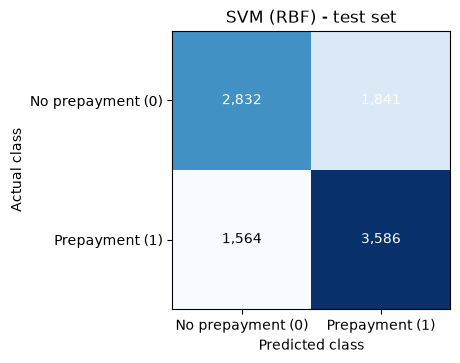

saved   p:\ML-Mini-Project\results\metrics\svm_metrics.csv
saved   p:\ML-Mini-Project\results\predictions\svm_predictions.csv
saved   p:\ML-Mini-Project\results\confusion_matrices\svm_confusion_matrix.png


In [8]:
metrics_df.to_csv(os.path.join(METRICS_DIR, "svm_metrics.csv"), index=False)

pred_df = pd.DataFrame({
    "row_index": X_test.index,
    "y_true": y_test.values,
    "y_pred": y_pred,
    "decision_score": decision_scores,
})
pred_df.to_csv(os.path.join(PRED_DIR, "svm_predictions.csv"), index=False)

plot_confusion(y_test, y_pred, "SVM (RBF) - test set", os.path.join(CM_DIR, "svm_confusion_matrix.png"))

for f in (os.path.join(METRICS_DIR, "svm_metrics.csv"), os.path.join(PRED_DIR, "svm_predictions.csv"),
          os.path.join(CM_DIR, "svm_confusion_matrix.png")):
    print(("saved   " if os.path.exists(f) else "MISSING ") + f)

## 7b. Save results in the shared `results/` layout
Writes the confusion matrix CSV, metrics JSON, test predictions CSV, and the confusion-matrix and ROC plots using the same file names as the other models.

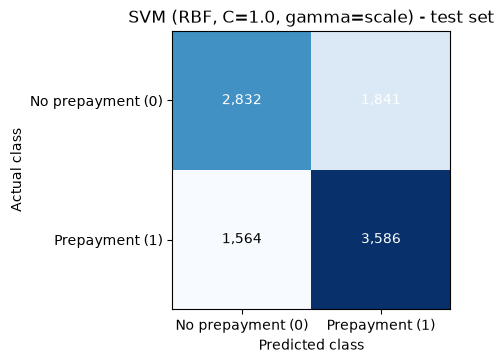

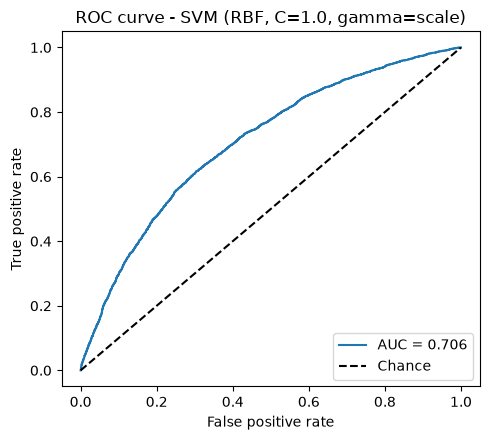

saved results for 'svm' to confusion_matrices/, metrics/ and plots/


In [9]:
import json
from sklearn.metrics import roc_curve

PLOTS_DIR = os.path.join(PROJECT_ROOT, "results", "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)


def save_in_team_format(name, y_true, y_pred, scores, metrics, extra_cols=None):
    """Save one model's results in the shared results/ layout:
    confusion_matrices/<name>_confusion_matrix.csv
    metrics/<name>_metrics.json, metrics/<name>_test_predictions.csv
    plots/<name>_confusion_matrix.png, plots/<name>_roc_curve.png
    """
    # 1) confusion matrix as CSV (rows = actual, columns = predicted)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]).to_csv(
        os.path.join(CM_DIR, f"{name}_confusion_matrix.csv"))

    # 2) metrics as JSON
    with open(os.path.join(METRICS_DIR, f"{name}_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2, default=float)

    # 3) test predictions as CSV
    out = {"row_index": np.arange(len(y_true)), "y_true": np.asarray(y_true),
           "y_pred": np.asarray(y_pred), "decision_score": np.asarray(scores)}
    if extra_cols:
        out.update(extra_cols)
    pd.DataFrame(out).to_csv(os.path.join(METRICS_DIR, f"{name}_test_predictions.csv"), index=False)

    # 4) plots: confusion matrix and ROC curve
    plot_confusion(y_true, y_pred, f"{metrics['model']} - test set",
                   os.path.join(PLOTS_DIR, f"{name}_confusion_matrix.png"))
    fpr, tpr, _ = roc_curve(y_true, scores)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", label="Chance")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC curve - {metrics['model']}"); ax.legend(loc="lower right")
    fig.tight_layout(); fig.savefig(os.path.join(PLOTS_DIR, f"{name}_roc_curve.png"), dpi=150)
    plt.show(); plt.close(fig)
    print(f"saved results for '{name}' to confusion_matrices/, metrics/ and plots/")

save_in_team_format("svm", y_test.values, y_pred, decision_scores, metrics)


## 8. Interpretation (fill in after running)
Read the numbers printed above, then answer in your own words:
- **Identifying prepayment:** what is the recall for class 1? What share of actual prepayments does the SVM catch?
- **False positives (FP)** are loans predicted to prepay that did not; **false negatives (FN)** are prepayments the model missed. Which is larger, and what would each cost a mortgage-backed-securities investor?
- **Precision vs recall:** precision = TP / (TP + FP); recall = TP / (TP + FN). Raising one usually lowers the other.
- **Why accuracy alone misleads:** if one class is much larger, always predicting it scores high accuracy while finding no prepayments. Compare accuracy with the majority-class baseline printed above, and look at precision, recall, F1 and ROC-AUC.

Do not call the SVM "best" or "worst" until all four models have been evaluated on the same test set.